In [3]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0 和 Step = 1、Step = 0 和 Step = 3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 仅筛选 Step 0 和 Step 1
        step_0_1_subset = subset[subset['Step'].isin([0, 1])]
        
        if step_0_1_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_1, p_value_0_1 = kruskal(step_0_1_subset[step_0_1_subset['Step'] == 0]['avg_beauty_score'], 
                                                    step_0_1_subset[step_0_1_subset['Step'] == 1]['avg_beauty_score'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 1):")
            print(f"H-statistic: {kruskal_stat_0_1}, p-value: {p_value_0_1}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_1 < 0.05:
                dunn_0_1 = sp.posthoc_dunn(step_0_1_subset, val_col='avg_beauty_score', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 1):")
                print(dunn_0_1)
        
        # 仅筛选 Step 0 和 Step 3
        step_0_3_subset = subset[subset['Step'].isin([0, 3])]
        
        if step_0_3_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_3, p_value_0_3 = kruskal(step_0_3_subset[step_0_3_subset['Step'] == 0]['avg_beauty_score'], 
                                                    step_0_3_subset[step_0_3_subset['Step'] == 3]['avg_beauty_score'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 3):")
            print(f"H-statistic: {kruskal_stat_0_3}, p-value: {p_value_0_3}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_3 < 0.05:
                dunn_0_3 = sp.posthoc_dunn(step_0_3_subset, val_col='avg_beauty_score', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 3):")
                print(dunn_0_3)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 1):
H-statistic: 0.1428571428571388, p-value: 0.7054569861112774

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 3):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 1):
H-statistic: 0.1428571428571388, p-value: 0.7054569861112774

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 3):
H-statistic: 0.28000000000000114, p-value: 0.5967012167293555

Kruskal-Wallis H Test for Black (Step 0 vs Step 1):
H-statistic: 1.6514285714285677, p-value: 0.19876460637323198

Kruskal-Wallis H Test for Black (Step 0 vs Step 3):
H-statistic: 4.805714285714274, p-value: 0.028365505605210242

Dunn's Test for Black (Step 0 vs Step 3):
          0         3
0  1.000000  0.028366
3  0.028366  1.000000

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 1):
H-statistic: 0.3657142857142901, p-value: 0.5453496680111212

Kruskal-Wallis H T

                     male_score                                        \
                          count     mean        std     min       25%   
race            Step                                                    
Black           0          10.0  43.7488   9.304124  34.553  36.95675   
                1          10.0  47.3861   7.819401  37.871  40.85875   
                2          10.0  48.9942   5.516895  42.489  43.77275   
                3          10.0  49.9613   4.509510  42.470  47.09100   
East Asian      0          10.0  55.1984  14.357203  32.489  50.87800   
                1          10.0  57.8968  12.630910  39.900  48.17450   
                2          10.0  57.9946  11.991588  41.790  49.56550   
                3          10.0  58.2791  10.866368  42.148  50.91625   
Indian          0          10.0  46.9389  13.429442  28.581  38.54400   
                1          10.0  51.7303  14.168065  35.109  40.47175   
                2          10.0  53.5282  12.031045

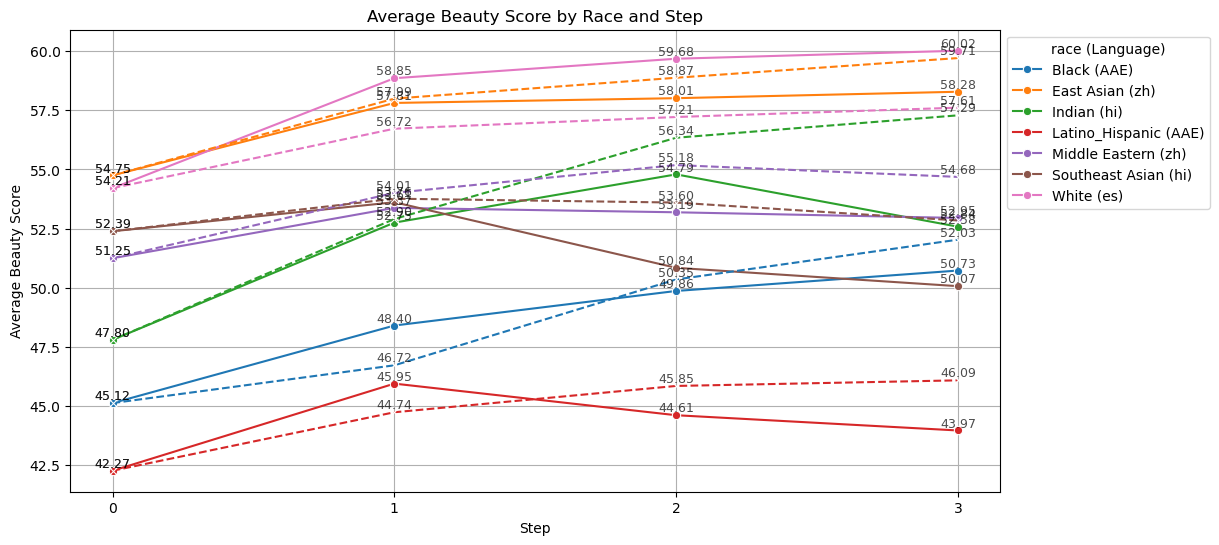

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    OA/SD
'''
# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 描述性统计，按种族和递进步骤分类
description_1 = data_1.groupby(['race', 'Step'])[['male_score', 'female_score', 'avg_beauty_score']].describe()
description_2 = data_2.groupby(['race', 'Step'])[['male_score', 'female_score', 'avg_beauty_score']].describe()
print(description_1)
print(description_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({
    'male_score': 'mean',
    'female_score': 'mean',
    'avg_beauty_score': 'mean'
}).reset_index()

mean_scores_2 = data_2.groupby(['Step', 'race']).agg({
    'male_score': 'mean',
    'female_score': 'mean',
    'avg_beauty_score': 'mean'
}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores_1['Language'] = mean_scores_1['race'].map(race_language_mapping)
mean_scores_2['Language'] = mean_scores_2['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='avg_beauty_score', hue='race', marker='o', linestyle='-', palette='tab10')

# 绘制第二个数据集
sns.lineplot(data=mean_scores_2, x='Step', y='avg_beauty_score', hue='race', marker='x', linestyle='--', palette='tab10', legend=False)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['avg_beauty_score'][i] + 0.02,
             f"{mean_scores_1['avg_beauty_score'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

for i in range(len(mean_scores_2)):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['avg_beauty_score'][i] + 0.02,
             f"{mean_scores_2['avg_beauty_score'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [f"{labels[i]} ({mean_scores_1['Language'][i]})" for i in range(len(labels)//2)] +
                     [f"{labels[i]} ({mean_scores_2['Language'][i - len(labels)//2]})" for i in range(len(labels)//2, len(labels))], 
           title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('Average Beauty Score by Race and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


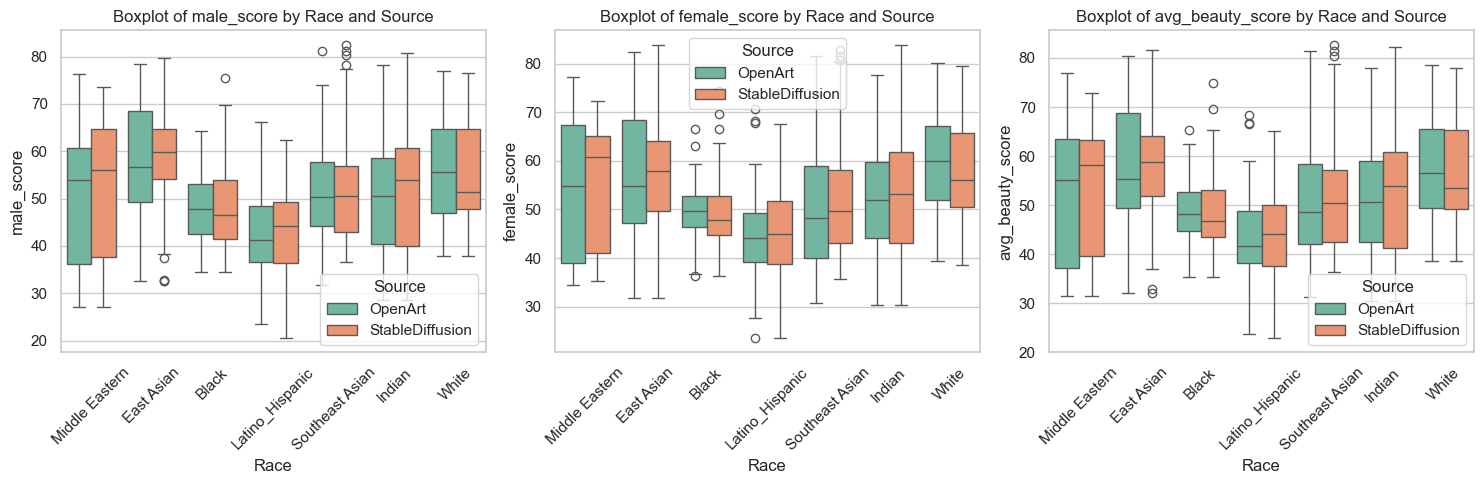

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取两个数据文件
file_path1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# 为每个数据框添加来源列
data1['Source'] = 'OpenArt'
data2['Source'] = 'StableDiffusion'

# 合并两个数据框
data = pd.concat([data1, data2], ignore_index=True)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 绘制箱线图
plt.figure(figsize=(15, 5))
for i, score_column in enumerate(score_columns):
    plt.subplot(1, 3, i + 1)  # 创建子图
    sns.boxplot(x='race', y=score_column, hue='Source', data=data, palette="Set2", dodge=True)
    plt.title(f'Boxplot of {score_column} by Race and Source')
    plt.xlabel('Race')
    plt.ylabel(score_column)
    plt.xticks(rotation=45)
    plt.legend(title='Source')

plt.tight_layout()
plt.show()

# 绘制小提琴图
# plt.figure(figsize=(15, 5))
# for i, score_column in enumerate(score_columns):
#     plt.subplot(1, 3, i + 1)  # 创建子图
#     sns.violinplot(x='race', y=score_column, hue='Source', data=data, inner='quartile', palette="Set2", split=True)
#     plt.title(f'Violin Plot of {score_column} by Race and Source')
#     plt.xlabel('Race')
#     plt.ylabel(score_column)
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


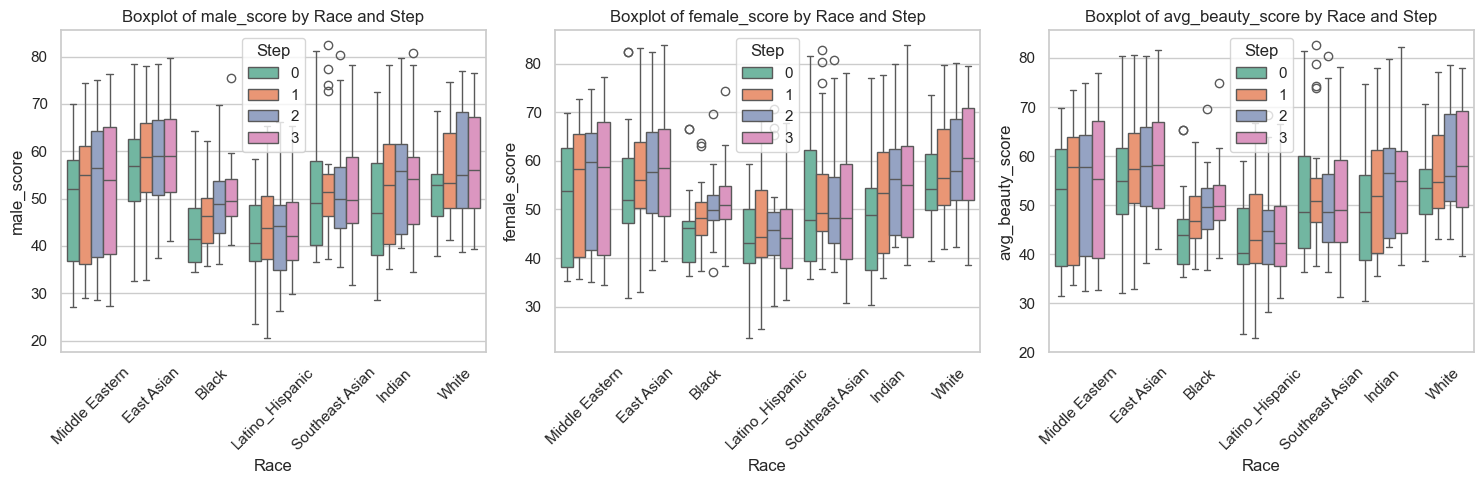

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(15, 5))
for i, score_column in enumerate(score_columns):
    plt.subplot(1, 3, i + 1)  # 创建子图
    sns.boxplot(x='race', y=score_column, hue='Step', data=data, palette="Set2")
    plt.title(f'Boxplot of {score_column} by Race and Step')
    plt.xlabel('Race')
    plt.ylabel(score_column)
    plt.xticks(rotation=45)
    plt.legend(title='Step')

plt.tight_layout()
plt.show()

# 绘制小提琴图
# plt.figure(figsize=(15, 5))
# for i, score_column in enumerate(score_columns):
#     plt.subplot(1, 3, i + 1)  # 创建子图
#     sns.violinplot(x='race', y=score_column, hue='Step', data=data, inner='quartile', palette="Set2", split=True)
#     plt.title(f'Violin Plot of {score_column} by Race and Step')
#     plt.xlabel('Race')
#     plt.ylabel(score_column)
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


d:\Anaconda3\envs\pytorch\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\Anaconda3\envs\pytorch\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\Anaconda3\envs\pytorch\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\Anaconda3\envs\pytorch\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

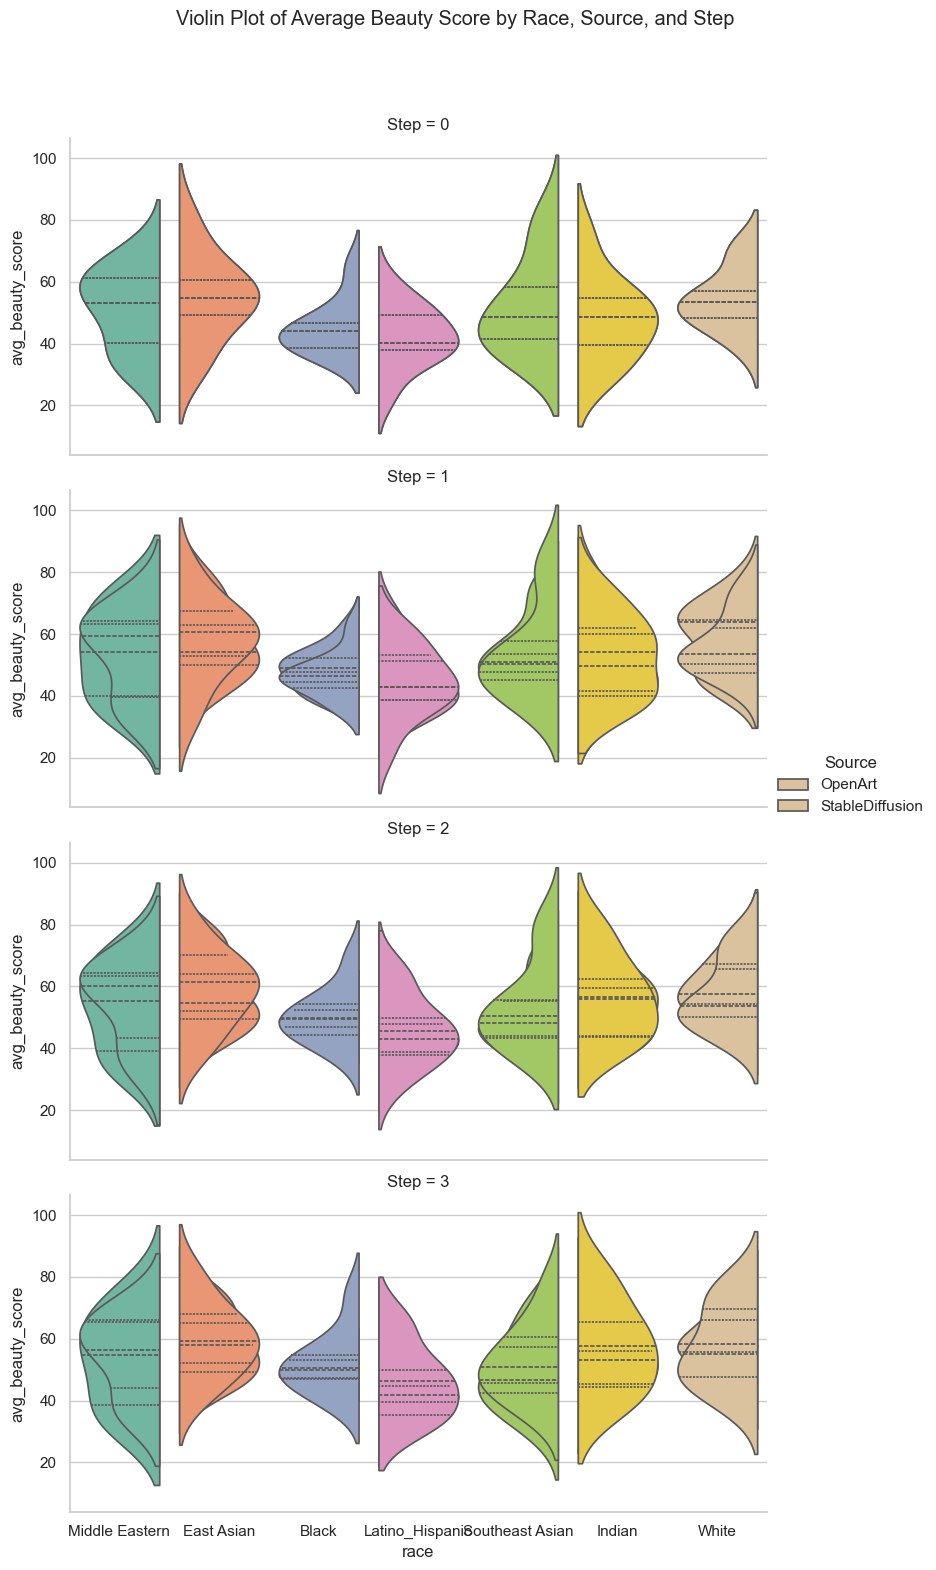

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取两个数据文件
file_path1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# 为每个数据框添加来源列
data1['Source'] = 'OpenArt'
data2['Source'] = 'StableDiffusion'

# 合并两个数据框
data = pd.concat([data1, data2], ignore_index=True)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 绘制Faceted小提琴图
g = sns.FacetGrid(data, row='Step', hue='Source', aspect=2, height=4)
g.map(sns.violinplot, 'race', 'avg_beauty_score', inner='quartile', palette="Set2", split=True, order=data['race'].unique())
g.add_legend()

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Violin Plot of Average Beauty Score by Race, Source, and Step')
plt.show()



                     male_score                                        \
                          count     mean        std     min       25%   
race            Step                                                    
Black           0          10.0  43.7488   9.304124  34.553  36.95675   
                1          10.0  47.3861   7.819401  37.871  40.85875   
                2          10.0  48.9942   5.516895  42.489  43.77275   
                3          10.0  49.9613   4.509510  42.470  47.09100   
East Asian      0          10.0  55.1984  14.357203  32.489  50.87800   
                1          10.0  57.8968  12.630910  39.900  48.17450   
                2          10.0  57.9946  11.991588  41.790  49.56550   
                3          10.0  58.2791  10.866368  42.148  50.91625   
Indian          0          10.0  46.9389  13.429442  28.581  38.54400   
                1          10.0  51.7303  14.168065  35.109  40.47175   
                2          10.0  53.5282  12.031045

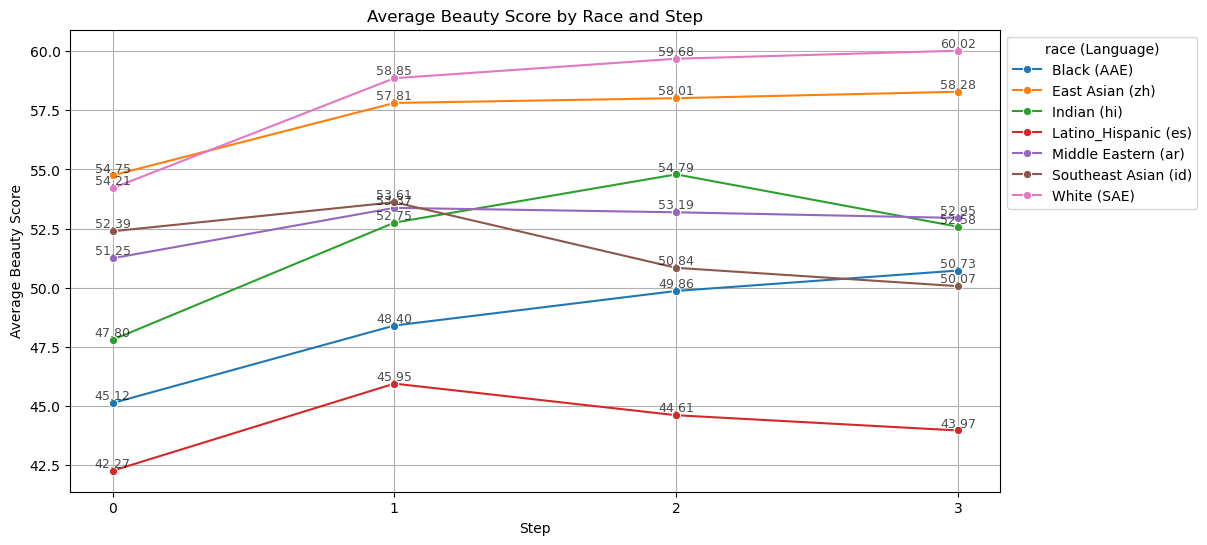

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    2024.10.09
    邹子露
    OA
'''
# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 描述性统计，按种族和递进步骤分类
description = data.groupby(['race', 'Step'])[['male_score', 'female_score', 'avg_beauty_score']].describe()
print(description)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores = data.groupby(['Step', 'race']).agg({
    'male_score': 'mean',
    'female_score': 'mean',
    'avg_beauty_score': 'mean'
}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores['Language'] = mean_scores['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))
sns.lineplot(data=mean_scores, x='Step', y='avg_beauty_score', hue='race', marker='o')

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores)):
    plt.text(mean_scores['Step'][i], mean_scores['avg_beauty_score'][i] + 0.02,  # 向上偏移0.02
             f"{mean_scores['avg_beauty_score'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [f"{labels[i]} ({mean_scores['Language'][i]})" for i in range(len(labels))], title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('Average Beauty Score by Race and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


                     male_score                                        \
                          count     mean        std     min       25%   
race            Step                                                    
Black           0          10.0  43.7488   9.304124  34.553  36.95675   
                1          10.0  46.0409   7.919559  35.723  41.67750   
                2          10.0  49.6656   9.684138  36.218  42.51025   
                3          10.0  51.7963  10.223200  40.241  46.10575   
East Asian      0          10.0  55.1984  14.357203  32.489  50.87800   
                1          10.0  57.9883  13.710918  32.714  55.03925   
                2          10.0  58.8228  13.099558  37.371  54.12775   
                3          10.0  59.7027  12.023547  40.952  54.75175   
Indian          0          10.0  46.9389  13.429442  28.581  38.54400   
                1          10.0  51.9355  13.313624  36.006  38.92550   
                2          10.0  55.7195  13.505906

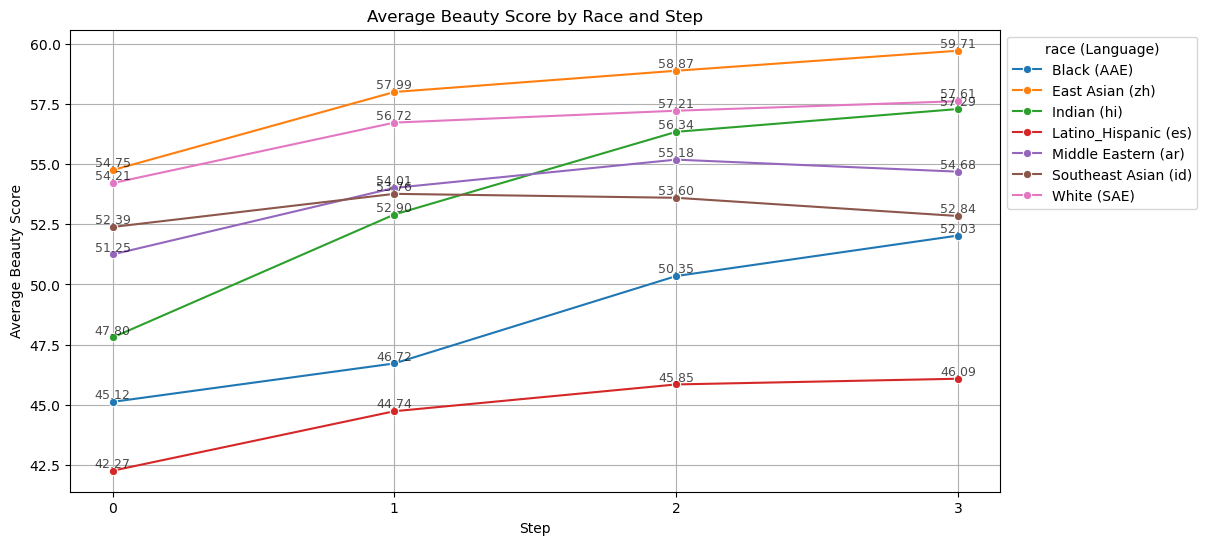

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    2024.10.09
    邹子露
    SD
'''
# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 描述性统计，按种族和递进步骤分类
description = data.groupby(['race', 'Step'])[['male_score', 'female_score', 'avg_beauty_score']].describe()
print(description)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores = data.groupby(['Step', 'race']).agg({
    'male_score': 'mean',
    'female_score': 'mean',
    'avg_beauty_score': 'mean'
}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores['Language'] = mean_scores['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))
sns.lineplot(data=mean_scores, x='Step', y='avg_beauty_score', hue='race', marker='o')

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores)):
    plt.text(mean_scores['Step'][i], mean_scores['avg_beauty_score'][i] + 0.02,  # 向上偏移0.02
             f"{mean_scores['avg_beauty_score'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [f"{labels[i]} ({mean_scores['Language'][i]})" for i in range(len(labels))], title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('Average Beauty Score by Race and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()

In [9]:
import pandas as pd
import scipy.stats as stats
'''
    差异分析Kruskal-Wallis H
'''
# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
print(normality_results)

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
print(levene_results)

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"\nANOVA Results for {score_column}:")
        print({'F-statistic': f_stat, 'p-value': p_value})
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"\nKruskal-Wallis H Test Results for {score_column}:")
        print({'H-statistic': h_stat, 'p-value': p_value})


Normality Test Results:
{'male_score': {'W-statistic': 0.9796854853630066, 'p-value': 0.0005103403236716986}, 'female_score': {'W-statistic': 0.9747169613838196, 'p-value': 7.33327615307644e-05}, 'avg_beauty_score': {'W-statistic': 0.9752135276794434, 'p-value': 8.8332082668785e-05}}

Levene's Test for Homogeneity of Variances Results:
{'male_score': {'W-statistic': 3.9647404308192145, 'p-value': 0.0008052099688778252}, 'female_score': {'W-statistic': 4.297682193805754, 'p-value': 0.00036888720523979985}, 'avg_beauty_score': {'W-statistic': 4.022827126798176, 'p-value': 0.0007029363341918104}}

Kruskal-Wallis H Test Results for male_score:
{'H-statistic': 37.66050838840886, 'p-value': 1.3087421176984346e-06}

Kruskal-Wallis H Test Results for female_score:
{'H-statistic': 41.63938028649065, 'p-value': 2.1662164792862515e-07}

Kruskal-Wallis H Test Results for avg_beauty_score:
{'H-statistic': 39.53560879801912, 'p-value': 5.619641065295302e-07}


In [10]:
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的颜值打分存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的颜值打分不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的颜值打分存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的颜值打分不存在显著差异。")


Normality Test Results:
male_score: W-statistic = 0.9797, p-value = 0.0005
  -> 数据不满足正态分布的假设。
female_score: W-statistic = 0.9747, p-value = 0.0001
  -> 数据不满足正态分布的假设。
avg_beauty_score: W-statistic = 0.9752, p-value = 0.0001
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
male_score: W-statistic = 3.9647, p-value = 0.0008
  -> 数据不满足方差齐性的假设。
female_score: W-statistic = 4.2977, p-value = 0.0004
  -> 数据不满足方差齐性的假设。
avg_beauty_score: W-statistic = 4.0228, p-value = 0.0007
  -> 数据不满足方差齐性的假设。

Analyzing male_score:
Kruskal-Wallis H Test Results: H-statistic = 37.6605, p-value = 0.0000
  -> 结果显著，说明不同种族之间的颜值打分存在差异。

Analyzing female_score:
Kruskal-Wallis H Test Results: H-statistic = 41.6394, p-value = 0.0000
  -> 结果显著，说明不同种族之间的颜值打分存在差异。

Analyzing avg_beauty_score:
Kruskal-Wallis H Test Results: H-statistic = 39.5356, p-value = 0.0000
  -> 结果显著，说明不同种族之间的颜值打分存在差异。


In [67]:
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的颜值打分存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的颜值打分不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的颜值打分存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的颜值打分不存在显著差异。")


Normality Test Results:
male_score: W-statistic = 0.9836, p-value = 0.0027
  -> 数据不满足正态分布的假设。
female_score: W-statistic = 0.9802, p-value = 0.0006
  -> 数据不满足正态分布的假设。
avg_beauty_score: W-statistic = 0.9786, p-value = 0.0003
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
male_score: W-statistic = 1.6696, p-value = 0.1285
  -> 数据满足方差齐性的假设。
female_score: W-statistic = 1.7145, p-value = 0.1176
  -> 数据满足方差齐性的假设。
avg_beauty_score: W-statistic = 1.8074, p-value = 0.0977
  -> 数据满足方差齐性的假设。

Analyzing male_score:
Kruskal-Wallis H Test Results: H-statistic = 31.3127, p-value = 0.0000
  -> 结果显著，说明不同种族之间的颜值打分存在差异。

Analyzing female_score:
Kruskal-Wallis H Test Results: H-statistic = 28.7394, p-value = 0.0001
  -> 结果显著，说明不同种族之间的颜值打分存在差异。

Analyzing avg_beauty_score:
Kruskal-Wallis H Test Results: H-statistic = 30.9543, p-value = 0.0000
  -> 结果显著，说明不同种族之间的颜值打分存在差异。


In [11]:
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印正态性检验结果
normality_df = pd.DataFrame(normality_results).T
print("Normality Test Results:")
print(normality_df)

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印方差齐性检验结果
levene_df = pd.DataFrame(levene_results).T
print("\nLevene's Test for Homogeneity of Variances Results:")
print(levene_df)

# 进行方差分析或Kruskal-Wallis H检验
results_summary = {}
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        results_summary[score_column] = {'Test': 'ANOVA', 'F-statistic': f_stat, 'p-value': p_value}
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    else:
        # Kruskal-Wallis H
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")

# 打印结果摘要
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)


Normality Test Results:
                  W-statistic   p-value
male_score           0.979685  0.000510
female_score         0.974717  0.000073
avg_beauty_score     0.975214  0.000088

Levene's Test for Homogeneity of Variances Results:
                  W-statistic   p-value
male_score           3.964740  0.000805
female_score         4.297682  0.000369
avg_beauty_score     4.022827  0.000703

Analyzing male_score:
Kruskal-Wallis H Test Results: H-statistic = 37.6605, p-value = 0.0000

Analyzing female_score:
Kruskal-Wallis H Test Results: H-statistic = 41.6394, p-value = 0.0000

Analyzing avg_beauty_score:
Kruskal-Wallis H Test Results: H-statistic = 39.5356, p-value = 0.0000

Statistical Test Results Summary:
                              Test H-statistic   p-value
male_score        Kruskal-Wallis H   37.660508  0.000001
female_score      Kruskal-Wallis H    41.63938       0.0
avg_beauty_score  Kruskal-Wallis H   39.535609  0.000001


In [16]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
                              Test H-statistic   p-value
male_score        Kruskal-Wallis H   37.660508  0.000001
female_score      Kruskal-Wallis H    41.63938       0.0
avg_beauty_score  Kruskal-Wallis H   39.535609  0.000001

Dunn's Test Results for male_score:
                    Black    East Asian    Indian  Latino_Hispanic  \
Black            1.000000  6.010257e-04  0.254655     8.586108e-02   
East Asian       0.000601  1.000000e+00  0.021904     2.621613e-07   
Indian           0.254655  2.190353e-02  1.000000     4.279876e-03   
Latino_Hispanic  0.085861  2.621613e-07  0.004280     1.000000e+00   
Middle Eastern   0.248376  2.279528e-02  0.987882     4.079482e-03   
Southeast Asian  0.154577  4.468548e-02  0.776078     1.682601e-03   
White            0.001567  7.877410e-01  0.043095     1.063268e-06   

                 Middle Eastern  Southeast Asian     White  
Black                  0.248376         0.154577  0.001567  
East Asian       

In [69]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
                              Test H-statistic   p-value
male_score        Kruskal-Wallis H   31.312679  0.000022
female_score      Kruskal-Wallis H   28.739413  0.000068
avg_beauty_score  Kruskal-Wallis H   30.954295  0.000026

Dunn's Test Results for male_score:
                    Black    East Asian    Indian  Latino_Hispanic  \
Black            1.000000  1.961927e-04  0.081663     2.388862e-01   
East Asian       0.000196  1.000000e+00  0.047395     9.503772e-07   
Indian           0.081663  4.739539e-02  1.000000     3.512748e-03   
Latino_Hispanic  0.238886  9.503772e-07  0.003513     1.000000e+00   
Middle Eastern   0.079036  4.911851e-02  0.987882     3.345348e-03   
Southeast Asian  0.094781  4.005632e-02  0.943861     4.392906e-03   
White            0.010183  2.483761e-01  0.407417     1.787185e-04   

                 Middle Eastern  Southeast Asian     White  
Black                  0.079036         0.094781  0.010183  
East Asian       

In [68]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['male_score', 'female_score', 'avg_beauty_score']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
                              Test H-statistic   p-value
male_score        Kruskal-Wallis H   31.312679  0.000022
female_score      Kruskal-Wallis H   28.739413  0.000068
avg_beauty_score  Kruskal-Wallis H   30.954295  0.000026

Dunn's Test Results for male_score:
                    Black    East Asian    Indian  Latino_Hispanic  \
Black            1.000000  1.961927e-04  0.081663     2.388862e-01   
East Asian       0.000196  1.000000e+00  0.047395     9.503772e-07   
Indian           0.081663  4.739539e-02  1.000000     3.512748e-03   
Latino_Hispanic  0.238886  9.503772e-07  0.003513     1.000000e+00   
Middle Eastern   0.079036  4.911851e-02  0.987882     3.345348e-03   
Southeast Asian  0.094781  4.005632e-02  0.943861     4.392906e-03   
White            0.010183  2.483761e-01  0.407417     1.787185e-04   

                 Middle Eastern  Southeast Asian     White  
Black                  0.079036         0.094781  0.010183  
East Asian       

In [56]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

race='race_Black + race_East_Asian + race_Indian + race_Latino_Hispanic + race_Middle_Eastern + race_Southeast_Asian + race_White'
jiaocha="+ Language_ar:race_Middle_Eastern + Language_zh:race_East_Asian + Language_es:race_Latino_Hispanic  + Language_id:race_Southeast_Asian + Language_hi:race_Indian + Language_AAE:race_Black + Gender:Step +"
language='Language_ar + Language_AAE + Language_zh + Language_hi + Language_id + Language_es + Language_SAE'
model = mixedlm("avg_beauty_score ~ Gender + Step +"+language, data, groups=data["Group"])
result = model.fit()

# 输出结果
print(result.summary())


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: avg_beauty_score
No. Observations: 280     Method:             REML            
No. Groups:       70      Scale:              15.5988         
Min. group size:  4       Log-Likelihood:     -890.9398       
Max. group size:  4       Converged:          Yes             
Mean group size:  4.0                                         
---------------------------------------------------------------
                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept       47.960     1.665  28.813  0.000  44.698  51.223
Gender           3.014     1.375   2.192  0.028   0.319   5.708
Step            -0.133     0.334  -0.399  0.690  -0.788   0.521
Language_ar      2.445     1.545   1.582  0.114  -0.584   5.473
Language_AAE     4.966     1.575   3.154  0.002   1.880   8.052
Language_zh      4.099     1.549   2.647  0.008   1.064   7.

Step              0          1          2          3
Language                                            
AAE       49.682179  51.770357  51.629400  53.123864
SAE       49.682179  54.269536  52.717614  52.414993
ar        49.682179  52.490943  53.658479  55.249043
es        49.682179  51.917214  50.870464  51.707707
hi        49.682179  52.368500  54.250879  53.771686
id        49.682179  50.974421  48.125021  49.514021
zh        49.682179  51.361271  52.437057  52.589900


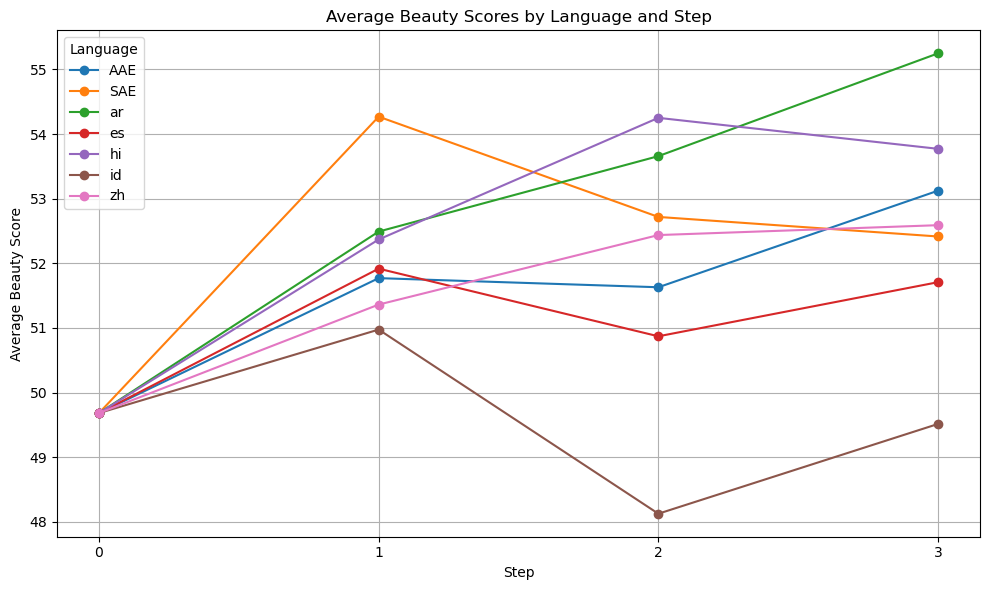

       avg_beauty_score   male_score  female_score
count       1540.000000  1540.000000   1540.000000
mean          52.131570    51.092489     53.170652
std           12.330113    12.570915     12.399933
min           23.610000    22.748000     23.643000
25%           42.854000    41.334000     44.287500
50%           50.459250    49.984000     51.161500
75%           59.791875    59.110500     61.073500
max           84.018500    83.348000     85.653000


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
'''
    新版折线图
    邹子露
    2024.10.03
'''
# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
avg_score_step_0 = df[df['Step'] == 0]['avg_beauty_score'].mean()

# 创建包含所有语言的初始行
languages = ['ar', 'zh', 'SAE', 'es', 'id', 'hi','AAE']
initial_rows = pd.DataFrame({'Language': languages, 'Average_Beauty_Score': avg_score_step_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi','Language_AAE']:
    avg_scores = df[df[lang] == 1].groupby('Step')['avg_beauty_score'].mean().reset_index()
    avg_scores['Language'] = lang.split('_')[1]  # 提取语言名
    avg_scores = avg_scores.rename(columns={'avg_beauty_score': 'Average_Beauty_Score'})  # 重命名列
    results = pd.concat([results, avg_scores], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Average_Beauty_Score', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Average_Beauty_Score')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Average Beauty Scores by Language and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''
# 选择颜值打分列
score_columns = ['avg_beauty_score', 'male_score', 'female_score']

# 描述性统计
descriptive_stats = df[score_columns].describe()

# 打印描述性统计结果
print(descriptive_stats)

In [10]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''
    新版beauty:统计分析：线性混合效应模型
    邹子露
    2024.10.03
'''
file_path=r'd:\Users\AAA\Desktop\face++\OpenB.csv'
# 读取数据
df = pd.read_csv(file_path)
jiaocha="+ Language_ar * Step + Language_zh * Step + Language_es * Step + Language_id * Step + Language_hi * Step+ Language_AAE * Step + Gender * Step"

# 定义线性混合效应模型
model_avg = mixedlm("avg_beauty_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step "+jiaocha, 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_male = mixedlm("male_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step"+jiaocha, 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_female = mixedlm("female_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step"+jiaocha, 
                df, 
                groups=df["Group"])
# 拟合模型
result_avg = model_avg.fit()
result_male = model_male.fit()
result_female = model_female.fit()
# 打印结果
print("openArt:")
print("平均颜值打分",result_avg.summary())
print("男性颜值打分",result_male.summary())
print("女性颜值打分",result_female.summary())


print("==========================================================")
file_path1=r'd:\Users\AAA\Desktop\face++\StabB.csv'
# 读取数据
df1 = pd.read_csv(file_path1)
# 定义线性混合效应模型
model_avg = mixedlm("avg_beauty_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step "+jiaocha, 
                df1, 
                groups=df1["Group"])
# 定义线性混合效应模型
model_male = mixedlm("male_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step"+jiaocha, 
                df1, 
                groups=df1["Group"])
# 定义线性混合效应模型
model_female = mixedlm("female_score ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step"+jiaocha, 
                df1, 
                groups=df1["Group"])
# 拟合模型
result_avg = model_avg.fit()
result_male = model_male.fit()
result_female = model_female.fit()
# 打印结果
print("stable diffusion")
print("平均颜值打分",result_avg.summary())
print("男性颜值打分",result_male.summary())
print("女性颜值打分",result_female.summary())

openArt:
平均颜值打分             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: avg_beauty_score
No. Observations: 1540    Method:             REML            
No. Groups:       70      Scale:              23.8528         
Min. group size:  22      Log-Likelihood:     -4786.3073      
Max. group size:  22      Converged:          Yes             
Mean group size:  22.0                                        
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           50.479    1.506 33.510 0.000 47.526 53.431
Language_ar         -0.167    1.018 -0.164 0.869 -2.162  1.827
Language_zh         -0.376    1.017 -0.369 0.712 -2.368  1.617
Language_es          0.465    1.017  0.457 0.648 -1.528  2.458
Language_id         -0.362    1.018 -0.356 0.722 -2.358  1.633
Language_hi          0.635    1.020  0.623 0.533 -1.

In [8]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''
    旧版beauty:统计分析：线性混合效应模型
'''
file_path=r'd:\Users\AAA\Desktop\face++\OpenA.csv'
# 读取数据
df = pd.read_csv(file_path)


# 定义线性混合效应模型
model_avg = mixedlm("avg_beauty_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_male = mixedlm("male_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_female = mixedlm("female_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 拟合模型
result_avg = model_avg.fit()
result_male = model_male.fit()
result_female = model_female.fit()
# 打印结果
print("平均颜值打分",result_avg.summary())
print("男性颜值打分",result_male.summary())
print("女性颜值打分",result_female.summary())

平均颜值打分             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: avg_beauty_score
No. Observations: 1330    Method:             REML            
No. Groups:       70      Scale:              22.8422         
Min. group size:  19      Log-Likelihood:     -4129.4013      
Max. group size:  19      Converged:          Yes             
Mean group size:  19.0                                        
---------------------------------------------------------------
                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept       51.300     1.479  34.686  0.000  48.401  54.199
Language_al      1.245     0.446   2.792  0.005   0.371   2.119
Language_cn     -0.407     0.444  -0.918  0.359  -1.277   0.463
Language_sp     -1.018     0.443  -2.300  0.021  -1.886  -0.150
Language_yn     -3.014     0.446  -6.765  0.000  -3.887  -2.141
Language_yd      0.856     0.457   1.872  0.061  -0.0

Step              0          1          2          3
Language                                            
AAE       49.682179  51.423843  53.576950  55.594636
SAE       49.682179  52.691271  53.540679  53.894464
ar        49.682179  52.718907  53.384021  53.697671
es        49.682179  51.199379  51.100579  50.892957
hi        49.682179  52.789614  54.523443  56.487107
id        49.682179  51.498057  51.337550  51.991971
zh        49.682179  52.044186  53.554829  54.843350


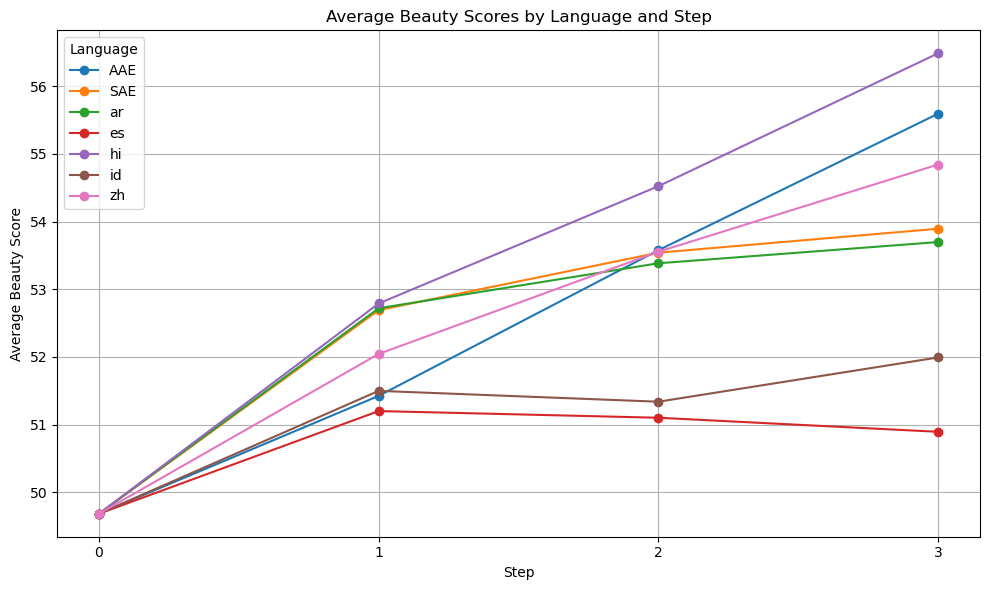

       avg_beauty_score   male_score  female_score
count       1540.000000  1540.000000   1540.000000
mean          52.839438    51.977494     53.701382
std           12.279538    12.562919     12.316758
min           22.973500    20.632000     23.643000
25%           43.276875    42.089000     44.828000
50%           51.612750    51.154000     52.024500
75%           60.402875    59.956500     61.410000
max           85.839500    85.613000     87.300000


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
'''
    新版折线图
    邹子露
    2024.10.03
'''
# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\StabB.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
avg_score_step_0 = df[df['Step'] == 0]['avg_beauty_score'].mean()

# 创建包含所有语言的初始行
languages = ['ar', 'zh', 'SAE', 'es', 'id', 'hi','AAE']
initial_rows = pd.DataFrame({'Language': languages, 'Average_Beauty_Score': avg_score_step_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi','Language_AAE']:
    avg_scores = df[df[lang] == 1].groupby('Step')['avg_beauty_score'].mean().reset_index()
    avg_scores['Language'] = lang.split('_')[1]  # 提取语言名
    avg_scores = avg_scores.rename(columns={'avg_beauty_score': 'Average_Beauty_Score'})  # 重命名列
    results = pd.concat([results, avg_scores], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Average_Beauty_Score', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Average_Beauty_Score')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Average Beauty Scores by Language and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''
# 选择颜值打分列
score_columns = ['avg_beauty_score', 'male_score', 'female_score']

# 描述性统计
descriptive_stats = df[score_columns].describe()

# 打印描述性统计结果
print(descriptive_stats)

Step              0          1          2          3
Language                                            
al        49.682179  52.490943  53.658479  55.249043
cn        49.682179  51.361271  52.437057  52.589900
en        49.682179  54.269536  52.717614  52.414993
sp        49.682179  51.917214  50.870464  51.707707
yd        49.682179  52.368500  54.250879  53.771686
yn        49.682179  50.974421  48.125021  49.514021


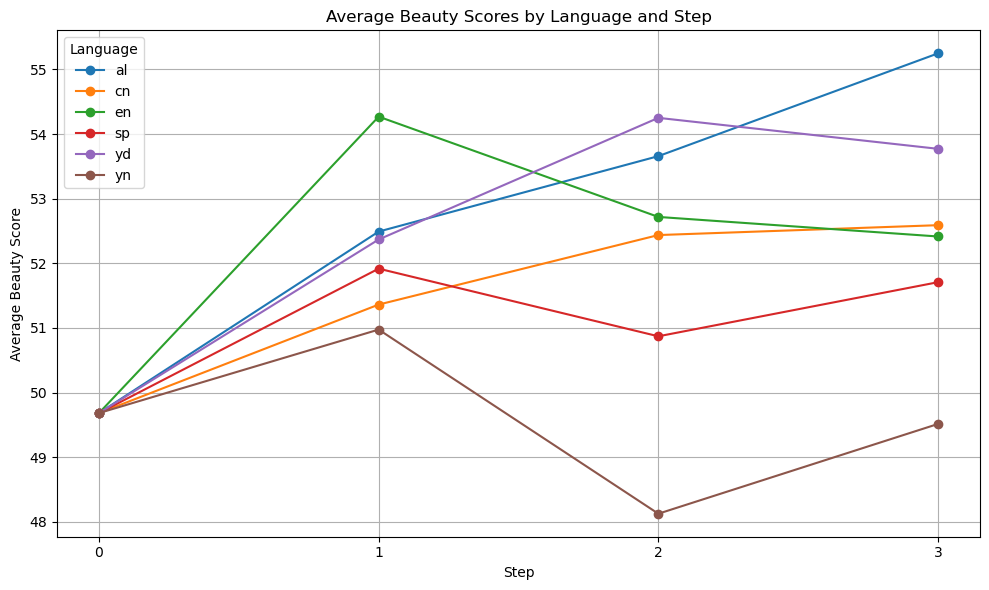

       avg_beauty_score   male_score  female_score
count       1330.000000  1330.000000   1330.000000
mean          52.124786    51.057823     53.191748
std           12.628182    12.895508     12.676565
min           23.610000    22.748000     23.643000
25%           42.652125    41.010750     44.145000
50%           50.348750    49.735500     51.089000
75%           60.022375    59.291000     61.651250
max           84.018500    83.348000     85.653000


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\OpenA.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
avg_score_step_0 = df[df['Step'] == 0]['avg_beauty_score'].mean()

# 创建包含所有语言的初始行
languages = ['ar', 'zh', 'SAE', 'es', 'id', 'hi']
initial_rows = pd.DataFrame({'Language': languages, 'Average_Beauty_Score': avg_score_step_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_al', 'Language_cn', 'Language_en', 'Language_sp', 'Language_yn', 'Language_yd']:
    avg_scores = df[df[lang] == 1].groupby('Step')['avg_beauty_score'].mean().reset_index()
    avg_scores['Language'] = lang.split('_')[1]  # 提取语言名
    avg_scores = avg_scores.rename(columns={'avg_beauty_score': 'Average_Beauty_Score'})  # 重命名列
    results = pd.concat([results, avg_scores], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Average_Beauty_Score', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Average_Beauty_Score')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Average Beauty Scores by Language and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''
# 选择颜值打分列
score_columns = ['avg_beauty_score', 'male_score', 'female_score']

# 描述性统计
descriptive_stats = df[score_columns].describe()

# 打印描述性统计结果
print(descriptive_stats)

In [11]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''统计分析：线性混合效应模型'''
file_path=r'd:\Users\AAA\Desktop\face++\StabA.csv'
# 读取数据
df = pd.read_csv(file_path)


# 定义线性混合效应模型
model_avg = mixedlm("avg_beauty_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_male = mixedlm("male_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model_female = mixedlm("female_score ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                df, 
                groups=df["Group"])
# 拟合模型
result_avg = model_avg.fit()
result_male = model_male.fit()
result_female = model_female.fit()
# 打印结果
print("stable diffusion")
print("平均颜值打分",result_avg.summary())
print("男性颜值打分",result_male.summary())
print("女性颜值打分",result_female.summary())

stable diffusion
平均颜值打分             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: avg_beauty_score
No. Observations: 1330    Method:             REML            
No. Groups:       70      Scale:              15.6731         
Min. group size:  19      Log-Likelihood:     -3893.2262      
Max. group size:  19      Converged:          Yes             
Mean group size:  19.0                                        
---------------------------------------------------------------
                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept       50.484     1.462  34.530  0.000  47.619  53.350
Language_al      0.326     0.367   0.890  0.373  -0.392   1.045
Language_cn      0.440     0.371   1.184  0.236  -0.288   1.168
Language_sp     -1.876     0.367  -5.118  0.000  -2.595  -1.158
Language_yn     -1.341     0.367  -3.657  0.000  -2.059  -0.622
Language_yd      1.602     0.368   4

Step              0          1          2          3
Language                                            
al        49.682179  52.718907  53.384021  53.697671
cn        49.682179  52.044186  53.554829  54.843350
en        49.682179  52.691271  53.540679  53.894464
sp        49.682179  51.199379  51.100579  50.892957
yd        49.682179  52.789614  54.523443  56.487107
yn        49.682179  51.498057  51.337550  51.991971


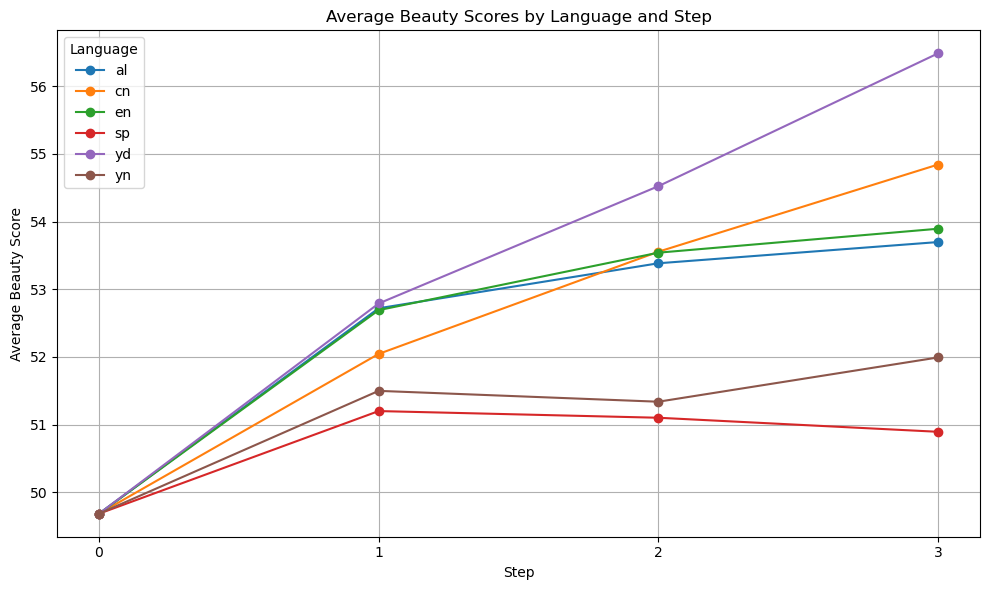

       avg_beauty_score   male_score  female_score
count       1330.000000  1330.000000   1330.000000
mean          52.730117    51.860321     53.599912
std           12.361079    12.670381     12.377847
min           22.973500    20.632000     23.643000
25%           43.008750    41.940250     44.611000
50%           51.487250    50.659000     51.917000
75%           60.443500    60.116000     61.420000
max           85.839500    84.794000     87.300000


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\StabA.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
avg_score_step_0 = df[df['Step'] == 0]['avg_beauty_score'].mean()

# 创建包含所有语言的初始行
languages = ['al', 'cn', 'en', 'sp', 'yn', 'yd']
initial_rows = pd.DataFrame({'Language': languages, 'Average_Beauty_Score': avg_score_step_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_al', 'Language_cn', 'Language_en', 'Language_sp', 'Language_yn', 'Language_yd']:
    avg_scores = df[df[lang] == 1].groupby('Step')['avg_beauty_score'].mean().reset_index()
    avg_scores['Language'] = lang.split('_')[1]  # 提取语言名
    avg_scores = avg_scores.rename(columns={'avg_beauty_score': 'Average_Beauty_Score'})  # 重命名列
    results = pd.concat([results, avg_scores], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Average_Beauty_Score', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Average_Beauty_Score')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Average Beauty Scores by Language and Step')
plt.xlabel('Step')
plt.ylabel('Average Beauty Score')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''
# 选择颜值打分列
score_columns = ['avg_beauty_score', 'male_score', 'female_score']

# 描述性统计
descriptive_stats = df[score_columns].describe()

# 打印描述性统计结果
print(descriptive_stats)